# Gesture Recognition - Data Preprocessing

This notebook handles data processing, augmentation, feature extraction, and dataset creation.

**Classes**:
- `grab` - 握拳
- `release` - 释放
- `swipe_up` - 上滑
- `swipe_down` - 下滑
- `noise` - 无效动作

**Notice**: Change the value of CACHE_VERSION after any optimization.

## 1. Environment Setup

In [1]:
# Check GPU
!nvidia-smi

Sun Apr  5 05:50:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080 Ti     Off |   00000000:21:00.0 Off |                  N/A |
| 30%   26C    P8             25W /  350W |    2331MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install dependencies
!pip install -q mediapipe onnx onnxruntime scikit-learn tqdm


[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import os
import json
import random
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
from tqdm import tqdm

# Import from common module
from common import (
    # Constants
    SEQ_LEN,
    NUM_LANDMARKS,
    NUM_COORDS,
    RAW_DIM,
    NUM_CLASSES,
    CLASS_NAMES,
    CLASS_TO_IDX,
    SWIPE_CLASSES,
    CACHE_VERSION,
    MIN_VALID_RATIO,
    WRIST_IDX,
    MID_FINGER_IDX,
    FINGERTIP_IDS,
    BASE_IDS,
    PAIRS,
    N_PAIRS,
    FINGER_CHAINS,
    N_FINGERS,
    FEATURE_DIM,
    # Logging
    log_info,
    log_warn,
    log_err,
    # Environment
    setup_environment,
    get_dataset_path,
    get_save_dir,
    # Utils
    to_scalar,
    resample,
    to_raw_sequence,
    interp_extrap_1d,
    interpolate_missing,
    # Features
    compute_features,
    # Augmentation
    mirror_x,
    rotate_2d,
    scale_landmarks,
    add_jitter,
    time_warp,
    speed_change,
    # Detection
    HandDetector,
)

# Print feature dimension for verification
print(f"Feature dim: {FEATURE_DIM}")
print(f"Classes: {CLASS_NAMES}")

Feature dim: 144
Classes: ['grab', 'release', 'swipe_up', 'swipe_down', 'noise']


## 2. Environment Setup and Dataset Path

In [4]:
# Setup environment and get paths
env = setup_environment()
print(f"Environment: {env}")

# Get dataset and save paths
DATASET_PATH = get_dataset_path()
TRAIN_DIR = f"{DATASET_PATH}/Train"
TEST_DIR = f"{DATASET_PATH}/Test"
save_dir = get_save_dir()

# Check if dataset exists
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATASET_PATH}")

print(f"Dataset path: {DATASET_PATH}")
print(f"Save dir: {save_dir}")

Environment: hpc
Dataset path: data
Save dir: checkpoints


## 3. Constants (Imported from common)

In [5]:
# Constants are already imported from common module
# Print constants for verification
print(f"SEQ_LEN: {SEQ_LEN}")
print(f"RAW_DIM: {RAW_DIM}")
print(f"FEATURE_DIM: {FEATURE_DIM}")
print(f"NUM_CLASSES: {NUM_CLASSES}")
print(f"CACHE_VERSION: {CACHE_VERSION}")

SEQ_LEN: 30
RAW_DIM: 63
FEATURE_DIM: 144
NUM_CLASSES: 5
CACHE_VERSION: v3_fixed_swipe_reverse


## 4. Preview Video Frames

In [6]:
import matplotlib.pyplot as plt


def preview_video_frames(video_path, num_frames=6, title=None):
    """Preview multiple frames from a video."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"Cannot open video: {video_path}")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Sample frames evenly
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    cap.release()

    # Plot frames
    fig, axes = plt.subplots(1, len(frames), figsize=(3 * len(frames), 3))
    if len(frames) == 1:
        axes = [axes]

    for ax, frame, idx in zip(axes, frames, frame_indices):
        ax.imshow(frame)
        ax.set_title(f"Frame {idx}")
        ax.axis("off")

    if title:
        fig.suptitle(f"{title}\n({total_frames} frames, {fps:.1f} FPS)", fontsize=12)
    plt.tight_layout()
    plt.show()

    return frames

=== Previewing sample videos ===


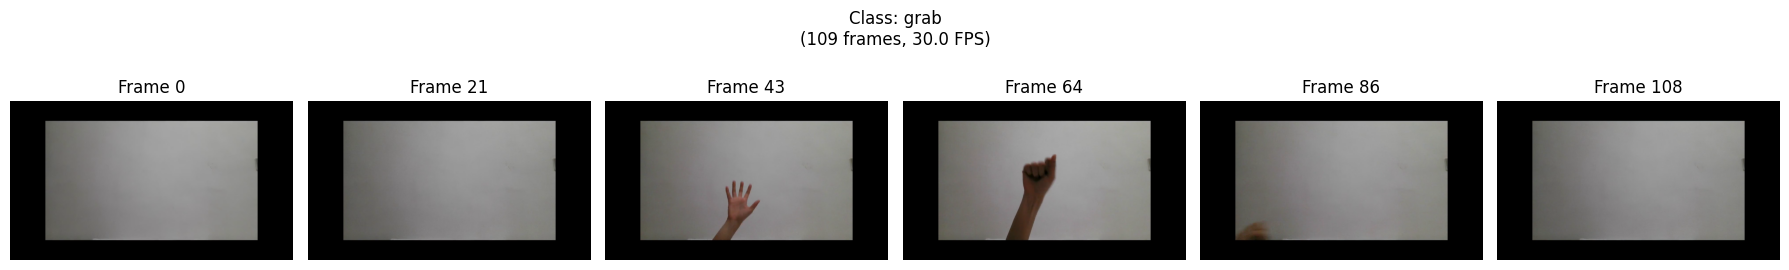

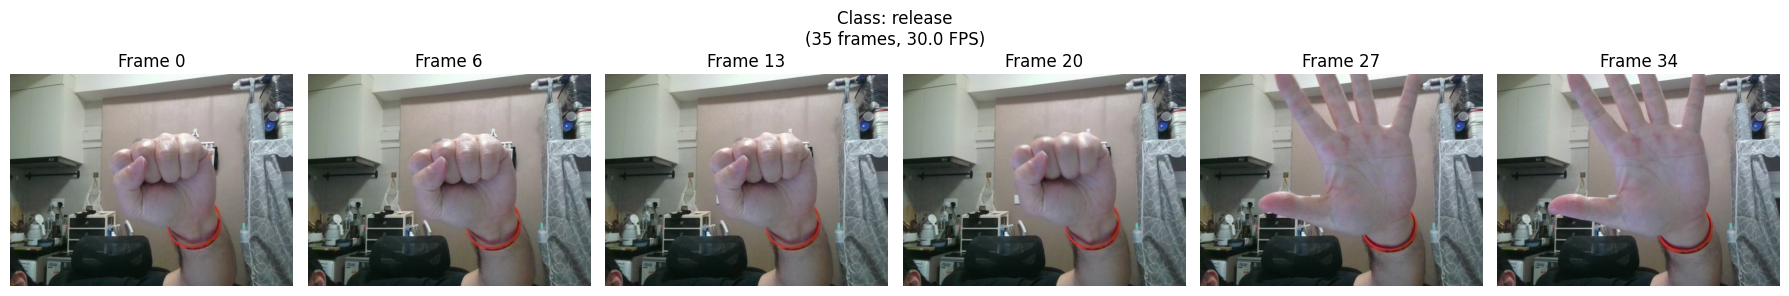

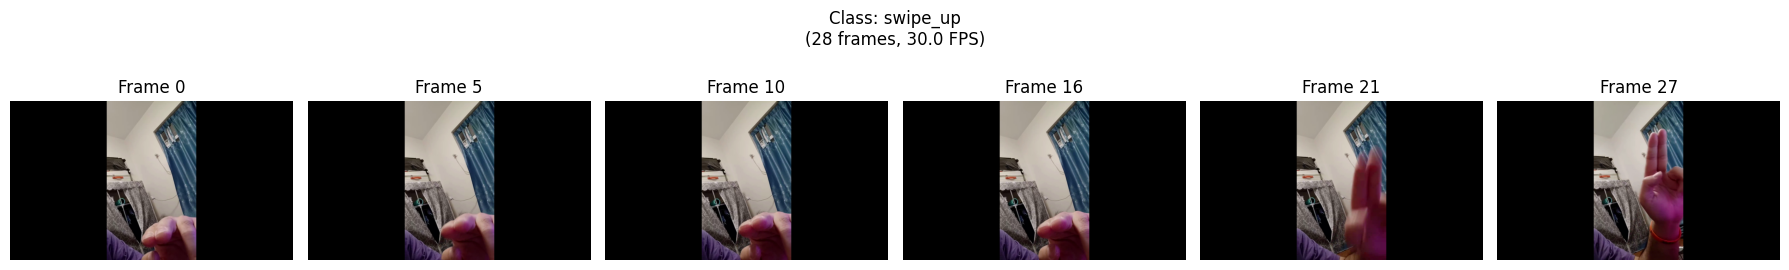

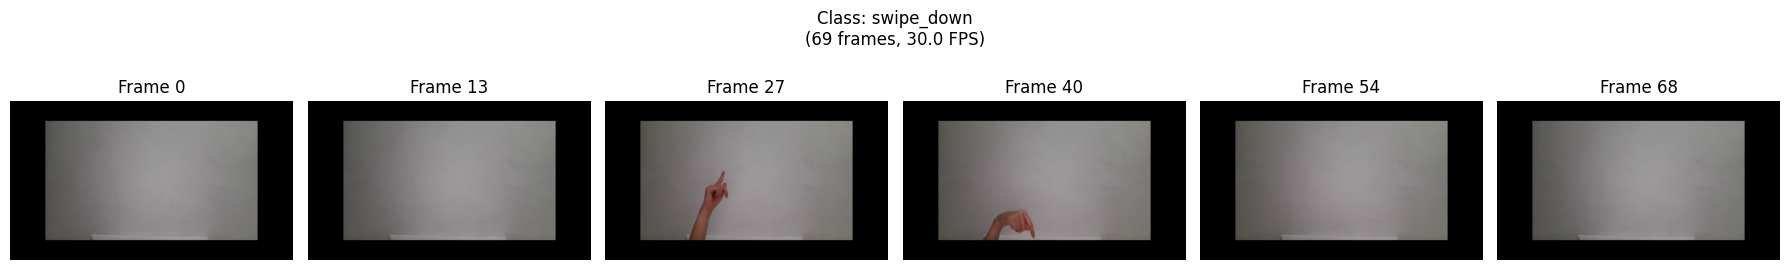

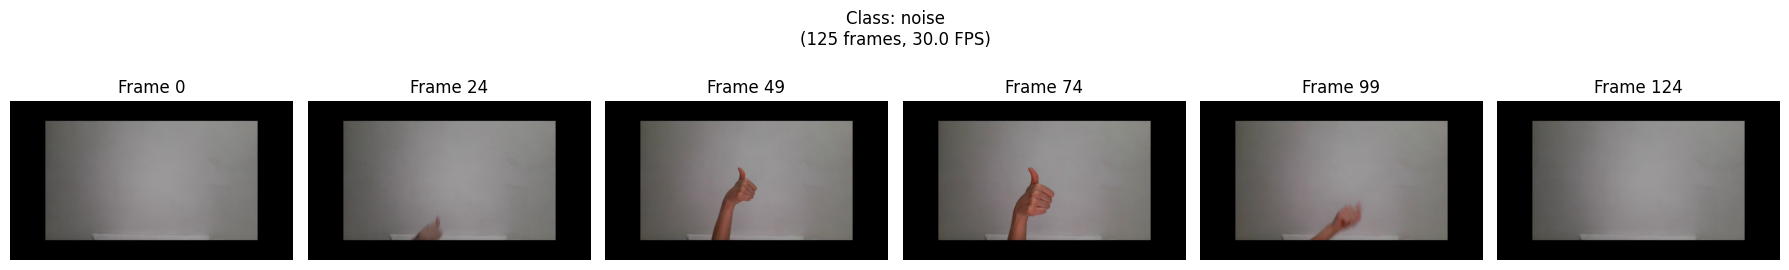

In [7]:
# Preview one video from each class
print("=== Previewing sample videos ===")
for class_name in CLASS_NAMES:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    if os.path.exists(class_dir):
        videos = [
            f
            for f in os.listdir(class_dir)
            if f.lower().endswith((".mp4", ".avi", ".mov", ".mkv", ".webm"))
        ]
        if videos:
            video_path = os.path.join(class_dir, videos[0])
            preview_video_frames(video_path, num_frames=6, title=f"Class: {class_name}")

## 5. Hand Landmark Detection (MediaPipe)

In [ ]:
# HandDetector is imported from common module
# Download MediaPipe model if needed
from common.detection import ensure_model_file

ensure_model_file()

'hand_landmarker.task'

## 6. Video Processing and Sample Generation

In [14]:
def extract_video(video_path, detector):
    """Extract hand landmarks from video."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return [], 0
    lms = []
    total = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        total += 1
        lms.append(detector.detect(frame))
    cap.release()
    return lms, total


def make_samples(lm_list, total_frames, class_name, is_train):
    """Generate training samples from landmark list."""
    valid = sum(1 for lm in lm_list if lm is not None)
    if total_frames == 0 or valid / total_frames < MIN_VALID_RATIO:
        return [], []
    raw = interpolate_missing(lm_list)
    n = len(raw)
    label = CLASS_TO_IDX[class_name]
    samples = []
    labels = []

    # Base sample
    base = resample(raw, SEQ_LEN)
    samples.append(base.astype(np.float32))
    labels.append(label)

    if not is_train:
        return samples, labels

    # Time-based cropping for longer sequences
    if n > SEQ_LEN:
        for start_r in [0.0, 0.15, 0.25]:
            for end_r in [0.75, 0.85, 1.0]:
                s = int(n * start_r)
                e = int(n * end_r)
                if e - s >= SEQ_LEN // 2:
                    sub = resample(raw[s:e], SEQ_LEN)
                    samples.append(sub.astype(np.float32))
                    labels.append(label)

    # Jitter augmentation
    for _ in range(3):
        aug = add_jitter(raw.copy())
        aug = resample(aug, SEQ_LEN)
        samples.append(aug.astype(np.float32))
        labels.append(label)

    # Rotation augmentation
    for angle in [-15, -10, -5, 5, 10, 15]:
        rot = rotate_2d(raw.copy(), angle)
        rot = resample(rot, SEQ_LEN)
        samples.append(rot.astype(np.float32))
        labels.append(label)

    # Scale augmentation
    for sc in [0.85, 0.9, 1.1, 1.15]:
        scaled = scale_landmarks(raw.copy(), sc)
        scaled = resample(scaled, SEQ_LEN)
        samples.append(scaled.astype(np.float32))
        labels.append(label)

    # Time warp augmentation
    for _ in range(2):
        tw = time_warp(raw.copy())
        tw = resample(tw, SEQ_LEN)
        samples.append(tw.astype(np.float32))
        labels.append(label)

    # Speed change augmentation
    for _ in range(2):
        sp = speed_change(raw.copy())
        sp = resample(sp, SEQ_LEN)
        samples.append(sp.astype(np.float32))
        labels.append(label)

    # Mirror (only for non-swipe gestures, label unchanged)
    if class_name not in SWIPE_CLASSES:
        mir = mirror_x(raw.copy())
        mir = resample(mir, SEQ_LEN)
        samples.append(mir.astype(np.float32))
        labels.append(label)

    # Reverse time augmentation
    # grab (PALM -> FIST) reversed = release (FIST -> PALM)
    # release (FIST -> PALM) reversed = grab (PALM -> FIST)
    # swipe_up reversed = swipe_down (direction flips)
    # swipe_down reversed = swipe_up (direction flips)
    # noise reversed = noise (unchanged)
    rev = raw[::-1].copy()
    rev = resample(rev, SEQ_LEN)
    samples.append(rev.astype(np.float32))

    if class_name == "grab":
        labels.append(CLASS_TO_IDX["release"])
    elif class_name == "release":
        labels.append(CLASS_TO_IDX["grab"])
    elif class_name == "swipe_up":
        labels.append(CLASS_TO_IDX["swipe_down"])
    elif class_name == "swipe_down":
        labels.append(CLASS_TO_IDX["swipe_up"])
    else:
        # noise - label unchanged
        labels.append(label)

    return samples, labels

## 7. Dataset Loading with Cache

In [15]:
def save_cache(cache_path, samples, labels, is_train):
    try:
        os.makedirs(os.path.dirname(os.path.abspath(cache_path)), exist_ok=True)
        if len(samples) == 0:
            sample_arr = np.zeros((0, SEQ_LEN, RAW_DIM), dtype=np.float32)
        else:
            sample_arr = np.stack(
                [to_raw_sequence(s, target_len=SEQ_LEN) for s in samples], axis=0
            ).astype(np.float32)
        label_arr = np.asarray(labels, dtype=np.int64)
        np.savez_compressed(
            cache_path,
            cache_version=np.array(CACHE_VERSION),
            sample_format=np.array("raw_landmarks"),
            raw_dim=np.array(RAW_DIM),
            seq_len=np.array(SEQ_LEN),
            is_train=np.array(int(is_train)),
            samples=sample_arr,
            labels=label_arr,
        )
        log_info(f"Cache saved: {cache_path}")
    except Exception as e:
        log_warn(f"Failed to save cache {cache_path}: {e}")


def try_load_cache(cache_path, is_train):
    if not cache_path or not os.path.exists(cache_path):
        return None
    log_info(f"Loading cache: {cache_path}")
    try:
        with np.load(cache_path, allow_pickle=True) as c:
            version = (
                to_scalar(c["cache_version"]) if "cache_version" in c.files else None
            )
            sample_format = (
                to_scalar(c["sample_format"]) if "sample_format" in c.files else None
            )
            raw_dim = to_scalar(c["raw_dim"]) if "raw_dim" in c.files else None
            seq_len = to_scalar(c["seq_len"]) if "seq_len" in c.files else None
            cache_is_train = to_scalar(c["is_train"]) if "is_train" in c.files else None
            if (
                version != CACHE_VERSION
                or sample_format != "raw_landmarks"
                or raw_dim != RAW_DIM
                or seq_len != SEQ_LEN
                or cache_is_train != int(is_train)
            ):
                raise ValueError("cache metadata mismatch")
            samples = np.asarray(c["samples"], dtype=np.float32)
            labels = np.asarray(c["labels"], dtype=np.int64)
        if (
            samples.ndim != 3
            or samples.shape[1] != SEQ_LEN
            or samples.shape[2] != RAW_DIM
        ):
            raise ValueError(f"cache sample shape mismatch: {samples.shape}")
        if len(samples) != len(labels):
            raise ValueError("cache sample/label count mismatch")
        out_samples = [np.ascontiguousarray(s, dtype=np.float32) for s in samples]
        out_labels = labels.astype(np.int64).tolist()
        log_info(f"  {len(out_samples)} samples loaded")
        return out_samples, out_labels
    except Exception as e:
        log_warn(f"Cache incompatible, rebuilding from videos: {e}")
        return None


def sanitize_dataset(samples, labels, name):
    fixed_samples = []
    fixed_labels = []
    if len(samples) != len(labels):
        log_warn(f"{name}: sample/label count mismatch, using min length")
    for s, l in zip(samples, labels):
        raw = to_raw_sequence(s, target_len=SEQ_LEN)
        if raw is None:
            continue
        fixed_samples.append(raw.astype(np.float32))
        fixed_labels.append(int(l))
    skipped = len(list(zip(samples, labels))) - len(fixed_samples)
    if skipped > 0:
        log_warn(f"{name}: skipped {skipped} invalid samples")
    return fixed_samples, fixed_labels

In [16]:
def load_dataset(data_dir, detector, cache_path=None, is_train=True):
    cached = try_load_cache(cache_path, is_train)
    if cached is not None:
        return cached

    all_samples, all_labels = [], []
    counts = defaultdict(int)
    dp = Path(data_dir)
    for cn in CLASS_NAMES:
        cd = dp / cn
        if not cd.exists():
            log_warn(f"Not found: {cd}")
            continue
        vfs = sorted(
            f
            for f in cd.iterdir()
            if f.suffix.lower() in (".mp4", ".avi", ".mov", ".mkv", ".webm")
        )
        log_info(f"  [{cn}]: {len(vfs)} videos")
        for vf in tqdm(vfs, desc=f"  {cn}", leave=False):
            lm_list, total = extract_video(vf, detector)
            if total == 0:
                continue
            samps, labs = make_samples(lm_list, total, cn, is_train)
            for s, l in zip(samps, labs):
                raw = to_raw_sequence(s, target_len=SEQ_LEN)
                if raw is None:
                    continue
                all_samples.append(raw.astype(np.float32))
                all_labels.append(int(l))
                counts[CLASS_NAMES[l]] += 1

    log_info("Dataset statistics:")
    for cn in CLASS_NAMES:
        log_info(f"  {cn:>15s}: {counts[cn]:>5d} samples")
    log_info(f"  {'Total':>15s}: {len(all_samples):>5d} samples")

    if cache_path:
        save_cache(cache_path, all_samples, all_labels, is_train)

    return all_samples, all_labels

## 8. Load and Process Datasets

In [17]:
# Load datasets
detector = HandDetector(static_mode=True, max_hands=1, min_conf=0.5)

cache_dir = os.path.join(save_dir, "cache")
tr_cache = os.path.join(cache_dir, f"train_{CACHE_VERSION}.npz")
te_cache = os.path.join(cache_dir, f"test_{CACHE_VERSION}.npz")

log_info("[Phase 1] Extracting landmarks ...")
train_samples, train_labels = load_dataset(TRAIN_DIR, detector, tr_cache, is_train=True)
test_samples, test_labels = load_dataset(TEST_DIR, detector, te_cache, is_train=False)
detector.close()

train_samples, train_labels = sanitize_dataset(train_samples, train_labels, "train")
test_samples, test_labels = sanitize_dataset(test_samples, test_labels, "test")

print(f"\nTrain samples: {len(train_samples)}")
print(f"Test samples: {len(test_samples)}")

I0000 00:00:1775339494.721039 1850978 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1775339494.764983 1851005 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.54.14), renderer: NVIDIA GeForce RTX 3080 Ti/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775339494.819403 1850980 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775339494.835077 1850999 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


[05:51:34] INFO - [Phase 1] Extracting landmarks ...
[05:51:34] INFO -   [grab]: 24 videos


  grab:   0%|          | 0/24 [00:00<?, ?it/s]W0000 00:00:1775339494.936600 1850983 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


[05:52:27] INFO -   [release]: 24 videos


[05:53:17] INFO -   [swipe_up]: 24 videos


...

[05:56:13] INFO -   [release]: 6 videos


[05:56:26] INFO -   [swipe_up]: 6 videos


[05:56:37] INFO -   [swipe_down]: 6 videos


[05:56:47] INFO -   [noise]: 9 videos


[05:57:07] INFO - Dataset statistics:
[05:57:07] INFO -              grab:     6 samples
[05:57:07] INFO -           release:     6 samples
[05:57:07] INFO -          swipe_up:     5 samples
[05:57:07] INFO -        swipe_down:     5 samples
[05:57:07] INFO -             noise:     7 samples
[05:57:07] INFO -             Total:    29 samples
[05:57:07] INFO - Cache saved: checkpoints/cache/test_v3_fixed_swipe_reverse.npz

Train samples: 3018
Test samples: 29


## 9. Normalization Statistics

In [18]:
def compute_norm_stats(samples):
    sum_feat = None
    sum_sq_feat = None
    total_frames = 0
    bad = 0

    for s in tqdm(samples, desc="Computing stats", leave=False):
        raw = to_raw_sequence(s, target_len=SEQ_LEN)
        if raw is None:
            bad += 1
            continue
        feat = compute_features(raw).astype(np.float64)
        cur_sum = feat.sum(axis=0)
        cur_sq = np.square(feat).sum(axis=0)
        if sum_feat is None:
            sum_feat = cur_sum
            sum_sq_feat = cur_sq
        else:
            sum_feat += cur_sum
            sum_sq_feat += cur_sq
        total_frames += feat.shape[0]

    if total_frames == 0:
        raise RuntimeError("No valid samples for normalization")

    mean64 = sum_feat / total_frames
    var64 = np.maximum(sum_sq_feat / total_frames - np.square(mean64), 1e-12)
    mean = mean64.astype(np.float32)
    std = np.sqrt(var64).astype(np.float32)

    if bad > 0:
        log_warn(f"Skipped {bad} invalid samples while computing normalization stats")

    return {"mean": mean, "std": std}


log_info("[Phase 2] Computing normalization stats ...")
norm_stats = compute_norm_stats(train_samples)
print(f"Mean range: [{norm_stats['mean'].min():.4f}, {norm_stats['mean'].max():.4f}]")
print(f"Std range:  [{norm_stats['std'].min():.4f}, {norm_stats['std'].max():.4f}]")

[05:57:07] INFO - [Phase 2] Computing normalization stats ...


Mean range: [-0.8790, 1.6513]
Std range:  [0.0000, 1.1398]


## 10. Save Preprocessed Data

In [19]:
import torch

os.makedirs(save_dir, exist_ok=True)

# Save normalization stats
norm_path = os.path.join(save_dir, "norm_stats.pt")
torch.save(norm_stats, norm_path)
log_info(f"Saved norm_stats to {norm_path}")

# Save dataset info
dataset_info = {
    "train_samples": len(train_samples),
    "test_samples": len(test_samples),
    "class_names": CLASS_NAMES,
    "cache_version": CACHE_VERSION,
    "seq_len": SEQ_LEN,
    "feature_dim": FEATURE_DIM,
    "raw_dim": RAW_DIM,
    "num_classes": NUM_CLASSES,
    "pairs": PAIRS,
    "fingertip_ids": FINGERTIP_IDS,
    "base_ids": BASE_IDS,
    "n_fingers": N_FINGERS,
    "finger_chains": FINGER_CHAINS,
}

info_path = os.path.join(save_dir, "dataset_info.json")
with open(info_path, "w", encoding="utf-8") as f:
    json.dump(dataset_info, f, indent=2, ensure_ascii=False)
log_info(f"Saved dataset_info to {info_path}")

# Save class distribution
train_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
test_counts = np.bincount(test_labels, minlength=NUM_CLASSES)
print("\nClass distribution:")
for i, cn in enumerate(CLASS_NAMES):
    print(f"  {cn:>12s}: train={train_counts[i]:>4d}, test={test_counts[i]:>3d}")

[05:57:08] INFO - Saved norm_stats to checkpoints/norm_stats.pt
[05:57:08] INFO - Saved dataset_info to checkpoints/dataset_info.json

Class distribution:
          grab: train= 612, test=  6
       release: train= 684, test=  6
      swipe_up: train= 471, test=  5
    swipe_down: train= 584, test=  5
         noise: train= 667, test=  7


In [ ]:
# Copy to Google Drive if in Colab
from common import detect_environment

if detect_environment() == "colab":
    import shutil

    drive_path = "/content/drive/MyDrive/checkpoints"
    shutil.copytree("checkpoints", drive_path, dirs_exist_ok=True)
    print(f"Files copied to: {drive_path}")
else:
    print("Skipping copy to Drive (not in Colab environment)")

Skipping copy to Drive (not in Colab environment)


## Summary

This notebook has:
1. Previewed sample videos from each class
2. Extracted hand landmarks using MediaPipe
3. Applied data augmentation for training data
4. Computed normalization statistics
5. Saved preprocessed data for training

**Output files:**
- `checkpoints/cache/train_{CACHE_VERSION}_raw.npz` - Training data cache
- `checkpoints/cache/test_{CACHE_VERSION}_raw.npz` - Test data cache
- `checkpoints/norm_stats.pt` - Normalization statistics
- `checkpoints/dataset_info.json` - Dataset metadata